[1573.98423528]
[  1.01433211 -21.55792498] 116.05021078278264
0.9706807451768623
0.9775935108325122


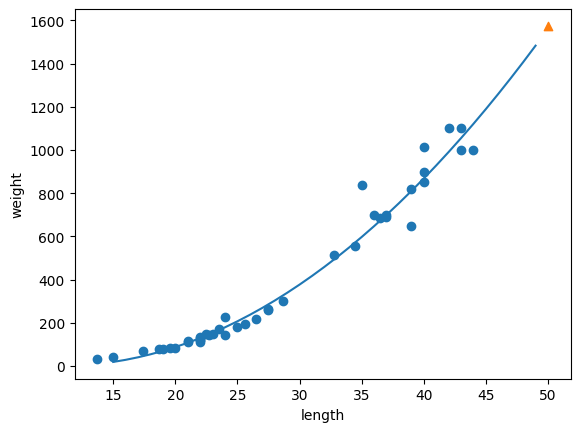

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression


# 최근접 이웃 개수 3 (과대적합[overfitting] 방지)
knr = KNeighborsRegressor(n_neighbors = 3)

lr = LinearRegression()


perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


# 훈련 / 테스트 입력, 목표 데이터 분배
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state = 42)


# 훈련 세트와 타겟 세트 2차원 배열로 변경
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)


# k-최근접 이웃 모델 training
knr.fit(train_input, train_target)


# 2차 방정식의 그래프 구현을 위해 length 를 제곱한 항을 훈련 세트에 추가
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

# 다항 회귀(Polynomial) 모델 훈련
lr.fit(train_poly, train_target)
print(lr.predict([[50 ** 2, 50]]))  

# 가중치 / 편향값 출력
# 무게 = 1.01 * 길이^2 - 21.6 * 길이 + 116.05
print(lr.coef_, lr.intercept_)     


# train / test set의 결정계수 점수 평가
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

# 구간별 직선을 그리기 위해 15 ~ 49 정수 배열 생성
point = np.arange(15, 50)

# train set 산점도
plt.scatter(train_input, train_target)

# 15 ~ 49 까지 2차 방정식 그래프 공식
# ax^2 + bx + c = 0
plt.plot(point, 1.01 * point ** 2 - 21.6 * point + 116.05)


# 50cm perch data
plt.scatter(50, 1574, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()